<a href="https://colab.research.google.com/github/kishore262/Smart-transitt/blob/main/SkinCancer_corrected_rerun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin lesion classification – corrected re-run (EfficientNet-B0 vs EfficientNet-V2-S)

**What this notebook fixes compared with the original code**
1. **One fixed train/validation/test split**, made once with a fixed seed and saved to `split.csv`. Training and testing use exactly the same images, so the test set is truly unseen.
2. **Split by `lesion_id`** – all images of the same lesion go to the same subset (no near-duplicate leakage).
3. **Identical training settings for both models** (optimiser, learning rate, batch size, epochs, scheduler, checkpoint rule).
4. **Correct per-sample focal loss** for both models.
5. Saves **everything the paper needs**: metrics, per-class report, confusion matrices, training curves, parameter counts, inference time, Grad-CAM figure.

## How to run
1. `Runtime` → `Change runtime type` → **T4 GPU** → Save.
2. Nothing else to prepare – the notebook **downloads HAM10000 from Kaggle automatically** (about 2–5 minutes). If Kaggle asks for a login token, the notebook shows a box to paste it.
3. (Optional) To use files you already have in Google Drive instead, set `DATA_SOURCE = "drive"` in the first code cell.
4. `Runtime` → **Run all**.
5. At the end, download **`results_for_paper.zip`** and send it back.

Expected time on a T4 GPU: about 60–90 minutes in total.

In [1]:
# ===== 1. SETTINGS (edit DATA_DIR if needed) =====
DATA_SOURCE = "kaggle"   # "kaggle" = download automatically (recommended) | "drive" = use files in Google Drive
DATA_DIR    = "/content/drive/MyDrive/HAM10000"   # only for "drive": folder with HAM10000_metadata.csv + images
ZIP_PATH    = "/content/drive/MyDrive/archive.zip" # only for "drive": or the Kaggle zip uploaded unchanged

SEED        = 42
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 20          # same for both models
LR          = 1e-4
WEIGHT_DECAY= 1e-5
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 1.0
OUT_DIR     = "/content/results_for_paper"

import os, sys, zipfile, subprocess, getpass, glob as _g
if DATA_SOURCE == "kaggle":
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub
    try:
        DATA_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    except Exception as e:
        print("Kaggle asked for a login token:", e)
        print("Get it at kaggle.com -> your profile picture -> Settings -> API -> 'Create New Token'.")
        os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ").strip()
        os.environ["KAGGLE_KEY"] = getpass.getpass("Kaggle key (from kaggle.json): ").strip()
        DATA_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
else:
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.isdir(DATA_DIR):
        zips = [ZIP_PATH] if os.path.exists(ZIP_PATH) else _g.glob("/content/drive/MyDrive/*.zip")
        assert zips, "Neither the HAM10000 folder nor a zip file was found in My Drive."
        print("Unzipping", zips[0], "... (about 2-4 minutes)")
        zipfile.ZipFile(zips[0]).extractall("/content/HAM10000")
        DATA_DIR = "/content/HAM10000"
print("Using data from:", DATA_DIR)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Using data from: /kaggle/input/skin-cancer-mnist-ham10000


In [2]:
# ===== 2. IMPORTS, SEED, DEVICE =====
import os, glob, json, time, random, shutil
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
from torchvision import models, transforms
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             balanced_accuracy_score, accuracy_score)
import matplotlib.pyplot as plt

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU"
print("PyTorch", torch.__version__, "| torchvision", torchvision.__version__, "| device:", gpu_name)
assert device.type == "cuda", "No GPU! Runtime -> Change runtime type -> T4 GPU, then run again."

PyTorch 2.11.0+cu130 | torchvision 0.26.0+cu130 | device: Tesla T4


In [3]:
# ===== 3. LOAD METADATA AND IMAGES (cached in memory at 224x224) =====
meta_files = glob.glob(os.path.join(DATA_DIR, "**", "HAM10000_metadata*"), recursive=True)
assert meta_files, f"HAM10000_metadata.csv not found under {DATA_DIR}"
meta = pd.read_csv(meta_files[0])
print("Metadata:", meta_files[0], "| rows:", len(meta))

paths = {os.path.splitext(os.path.basename(p))[0]: p
         for p in glob.glob(os.path.join(DATA_DIR, "**", "*.jpg"), recursive=True)}
meta["path"] = meta["image_id"].map(paths)
missing = meta["path"].isna().sum()
print("Images found:", len(paths), "| metadata rows without image:", missing)
meta = meta.dropna(subset=["path"]).reset_index(drop=True)

CLASSES = sorted(meta["dx"].unique())          # akiec, bcc, bkl, df, mel, nv, vasc
cls2idx = {c: i for i, c in enumerate(CLASSES)}
meta["label"] = meta["dx"].map(cls2idx)
print("Classes:", CLASSES)
print(meta["dx"].value_counts().reindex(CLASSES))

def load_resized(p):
    return np.asarray(Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
t0 = time.time()
with ThreadPoolExecutor(16) as ex:
    IMAGES = np.stack(list(ex.map(load_resized, meta["path"])))
print("Loaded", IMAGES.shape, f"in {time.time()-t0:.0f}s")

Metadata: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv | rows: 10015
Images found: 10015 | metadata rows without image: 0
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
dx
akiec     327
bcc       514
bkl      1099
df        115
mel      1113
nv       6705
vasc      142
Name: count, dtype: int64
Loaded (10015, 224, 224, 3) in 69s


In [4]:
# ===== 4. FIXED LESION-LEVEL SPLIT (72% train / 8% val / 20% test), saved to split.csv =====
y, groups = meta["label"].values, meta["lesion_id"].values
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
trval_idx, test_idx = next(sgkf.split(np.zeros(len(y)), y, groups))
sgkf2 = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
tr_sub, val_sub = next(sgkf2.split(np.zeros(len(trval_idx)), y[trval_idx], groups[trval_idx]))
train_idx, val_idx = trval_idx[tr_sub], trval_idx[val_sub]

meta["split"] = ""
meta.loc[train_idx, "split"] = "train"; meta.loc[val_idx, "split"] = "val"; meta.loc[test_idx, "split"] = "test"
meta[["image_id", "lesion_id", "dx", "split"]].to_csv(f"{OUT_DIR}/split.csv", index=False)

# leakage check: no lesion may appear in two subsets
L = {s: set(meta.loc[meta.split == s, "lesion_id"]) for s in ["train", "val", "test"]}
assert not (L["train"] & L["test"]) and not (L["val"] & L["test"]) and not (L["train"] & L["val"])
counts = pd.crosstab(meta["dx"], meta["split"]).reindex(CLASSES)[["train", "val", "test"]]
counts.loc["TOTAL"] = counts.sum()
print(counts); counts.to_csv(f"{OUT_DIR}/class_counts_per_split.csv")
print("No lesion shared between subsets: OK")

split  train  val  test
dx                     
akiec    242   17    68
bcc      375   39   100
bkl      810   84   205
df        83   10    22
mel      805   86   222
nv      4786  556  1363
vasc     100    8    34
TOTAL   7201  800  2014
No lesion shared between subsets: OK


In [5]:
# ===== 5. DATASETS AND AUGMENTATION (same augmentation as the original code) =====
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
test_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class HamDS(torch.utils.data.Dataset):
    def __init__(self, idx, tf): self.idx, self.tf = np.asarray(idx), tf
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        return self.tf(Image.fromarray(IMAGES[j])), int(meta.at[j, "label"])

g = torch.Generator().manual_seed(SEED)
def loader(idx, tf, shuffle):
    return torch.utils.data.DataLoader(HamDS(idx, tf), batch_size=BATCH_SIZE, shuffle=shuffle,
                                       num_workers=2, pin_memory=True, generator=g)
train_dl, val_dl, test_dl = loader(train_idx, train_tf, True), loader(val_idx, test_tf, False), loader(test_idx, test_tf, False)
print(len(train_idx), "train |", len(val_idx), "val |", len(test_idx), "test")

7201 train | 800 val | 2014 test


In [6]:
# ===== 6. FOCAL LOSS (per sample), MODELS, TRAINING LOOP =====
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__(); self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, target):
        logpt = -F.cross_entropy(logits, target, reduction="none")
        pt = logpt.exp()
        return (-self.alpha * (1 - pt) ** self.gamma * logpt).mean()

def build(name):
    if name == "EfficientNet-B0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    else:
        m = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(CLASSES))   # all layers fine-tuned
    return m.to(device)

@torch.no_grad()
def predict(model, dl):
    model.eval(); P, Y, loss_sum, n = [], [], 0.0, 0
    crit = FocalLoss(FOCAL_ALPHA, FOCAL_GAMMA)
    for x, t in dl:
        x, t = x.to(device, non_blocking=True), t.to(device)
        with torch.autocast("cuda", dtype=torch.float16):
            out = model(x)
        loss_sum += crit(out.float(), t).item() * len(t); n += len(t)
        P.append(out.float().argmax(1).cpu()); Y.append(t.cpu())
    return torch.cat(Y).numpy(), torch.cat(P).numpy(), loss_sum / n

def train(name):
    set_seed(SEED)
    model = build(name)
    crit = FocalLoss(FOCAL_ALPHA, FOCAL_GAMMA)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.cuda.amp.GradScaler()
    hist, best, ckpt = [], -1, f"/content/{name}_best.pth"
    for ep in range(1, EPOCHS + 1):
        model.train(); t0 = time.time(); tl, tc, tn = 0.0, 0, 0
        for x, t in train_dl:
            x, t = x.to(device, non_blocking=True), t.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16):
                out = model(x); loss = crit(out.float(), t)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tl += loss.item() * len(t); tc += (out.argmax(1) == t).sum().item(); tn += len(t)
        sched.step()
        yv, pv, vl = predict(model, val_dl)
        row = dict(epoch=ep, train_loss=tl/tn, train_acc=tc/tn, val_loss=vl,
                   val_acc=accuracy_score(yv, pv), val_macro_f1=f1_score(yv, pv, average="macro"))
        hist.append(row)
        flag = ""
        if row["val_macro_f1"] > best:
            best = row["val_macro_f1"]; torch.save(model.state_dict(), ckpt); flag = "  <- best (saved)"
        print(f"{name} | epoch {ep:2d}/{EPOCHS} | train loss {row['train_loss']:.4f} acc {row['train_acc']:.4f} | "
              f"val loss {vl:.4f} acc {row['val_acc']:.4f} macroF1 {row['val_macro_f1']:.4f} | {time.time()-t0:.0f}s{flag}")
    pd.DataFrame(hist).to_csv(f"{OUT_DIR}/history_{name}.csv", index=False)
    model.load_state_dict(torch.load(ckpt)); return model

In [7]:
# ===== 7. TRAIN EfficientNet-B0 =====
model_b0 = train("EfficientNet-B0")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 219MB/s]
/tmp/ipykernel_3473/4017970742.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


EfficientNet-B0 | epoch  1/20 | train loss 0.5389 acc 0.7013 | val loss 0.2853 acc 0.8237 macroF1 0.5679 | 47s  <- best (saved)
EfficientNet-B0 | epoch  2/20 | train loss 0.2944 acc 0.7993 | val loss 0.2312 acc 0.8375 macroF1 0.6245 | 39s  <- best (saved)
EfficientNet-B0 | epoch  3/20 | train loss 0.2398 acc 0.8239 | val loss 0.2028 acc 0.8525 macroF1 0.6764 | 39s  <- best (saved)
EfficientNet-B0 | epoch  4/20 | train loss 0.1952 acc 0.8439 | val loss 0.1954 acc 0.8488 macroF1 0.6930 | 40s  <- best (saved)
EfficientNet-B0 | epoch  5/20 | train loss 0.1655 acc 0.8603 | val loss 0.1927 acc 0.8612 macroF1 0.7212 | 39s  <- best (saved)
EfficientNet-B0 | epoch  6/20 | train loss 0.1512 acc 0.8714 | val loss 0.2017 acc 0.8538 macroF1 0.6962 | 40s
EfficientNet-B0 | epoch  7/20 | train loss 0.1288 acc 0.8818 | val loss 0.1999 acc 0.8512 macroF1 0.6792 | 39s
EfficientNet-B0 | epoch  8/20 | train loss 0.1163 acc 0.8945 | val loss 0.1807 acc 0.8700 macroF1 0.7422 | 39s  <- best (saved)
EfficientN

In [8]:
# ===== 8. TRAIN EfficientNet-V2-S =====
model_v2 = train("EfficientNet-V2-S")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 144MB/s]
/tmp/ipykernel_3473/4017970742.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


EfficientNet-V2-S | epoch  1/20 | train loss 0.4628 acc 0.7355 | val loss 0.2487 acc 0.8300 macroF1 0.6257 | 54s  <- best (saved)
EfficientNet-V2-S | epoch  2/20 | train loss 0.2342 acc 0.8270 | val loss 0.2283 acc 0.8400 macroF1 0.6893 | 55s  <- best (saved)
EfficientNet-V2-S | epoch  3/20 | train loss 0.1761 acc 0.8567 | val loss 0.2124 acc 0.8275 macroF1 0.6971 | 53s  <- best (saved)
EfficientNet-V2-S | epoch  4/20 | train loss 0.1371 acc 0.8838 | val loss 0.1725 acc 0.8438 macroF1 0.7461 | 53s  <- best (saved)
EfficientNet-V2-S | epoch  5/20 | train loss 0.1079 acc 0.9002 | val loss 0.1938 acc 0.8538 macroF1 0.7032 | 53s
EfficientNet-V2-S | epoch  6/20 | train loss 0.0901 acc 0.9150 | val loss 0.2465 acc 0.8488 macroF1 0.6798 | 53s
EfficientNet-V2-S | epoch  7/20 | train loss 0.0682 acc 0.9304 | val loss 0.2267 acc 0.8400 macroF1 0.6776 | 53s
EfficientNet-V2-S | epoch  8/20 | train loss 0.0604 acc 0.9358 | val loss 0.2168 acc 0.8575 macroF1 0.6911 | 57s
EfficientNet-V2-S | epoch  9


===== EfficientNet-B0 =====
              precision    recall  f1-score   support

       akiec     0.6964    0.5735    0.6290        68
         bcc     0.7292    0.7000    0.7143       100
         bkl     0.6332    0.7073    0.6682       205
          df     0.6250    0.2273    0.3333        22
         mel     0.6098    0.5631    0.5855       222
          nv     0.9194    0.9376    0.9284      1363
        vasc     0.9333    0.8235    0.8750        34

    accuracy                         0.8391      2014
   macro avg     0.7352    0.6475    0.6763      2014
weighted avg     0.8362    0.8391    0.8360      2014

       akiec  bcc  bkl  df  mel    nv  vasc
akiec     39    3   17   0    5     4     0
bcc        5   70    9   0    7     8     1
bkl        7    6  145   1   17    29     0
df         2    2    7   5    3     3     0
mel        0    3   26   2  125    66     0
nv         3   11   25   0   45  1278     1
vasc       0    1    0   0    3     2    28


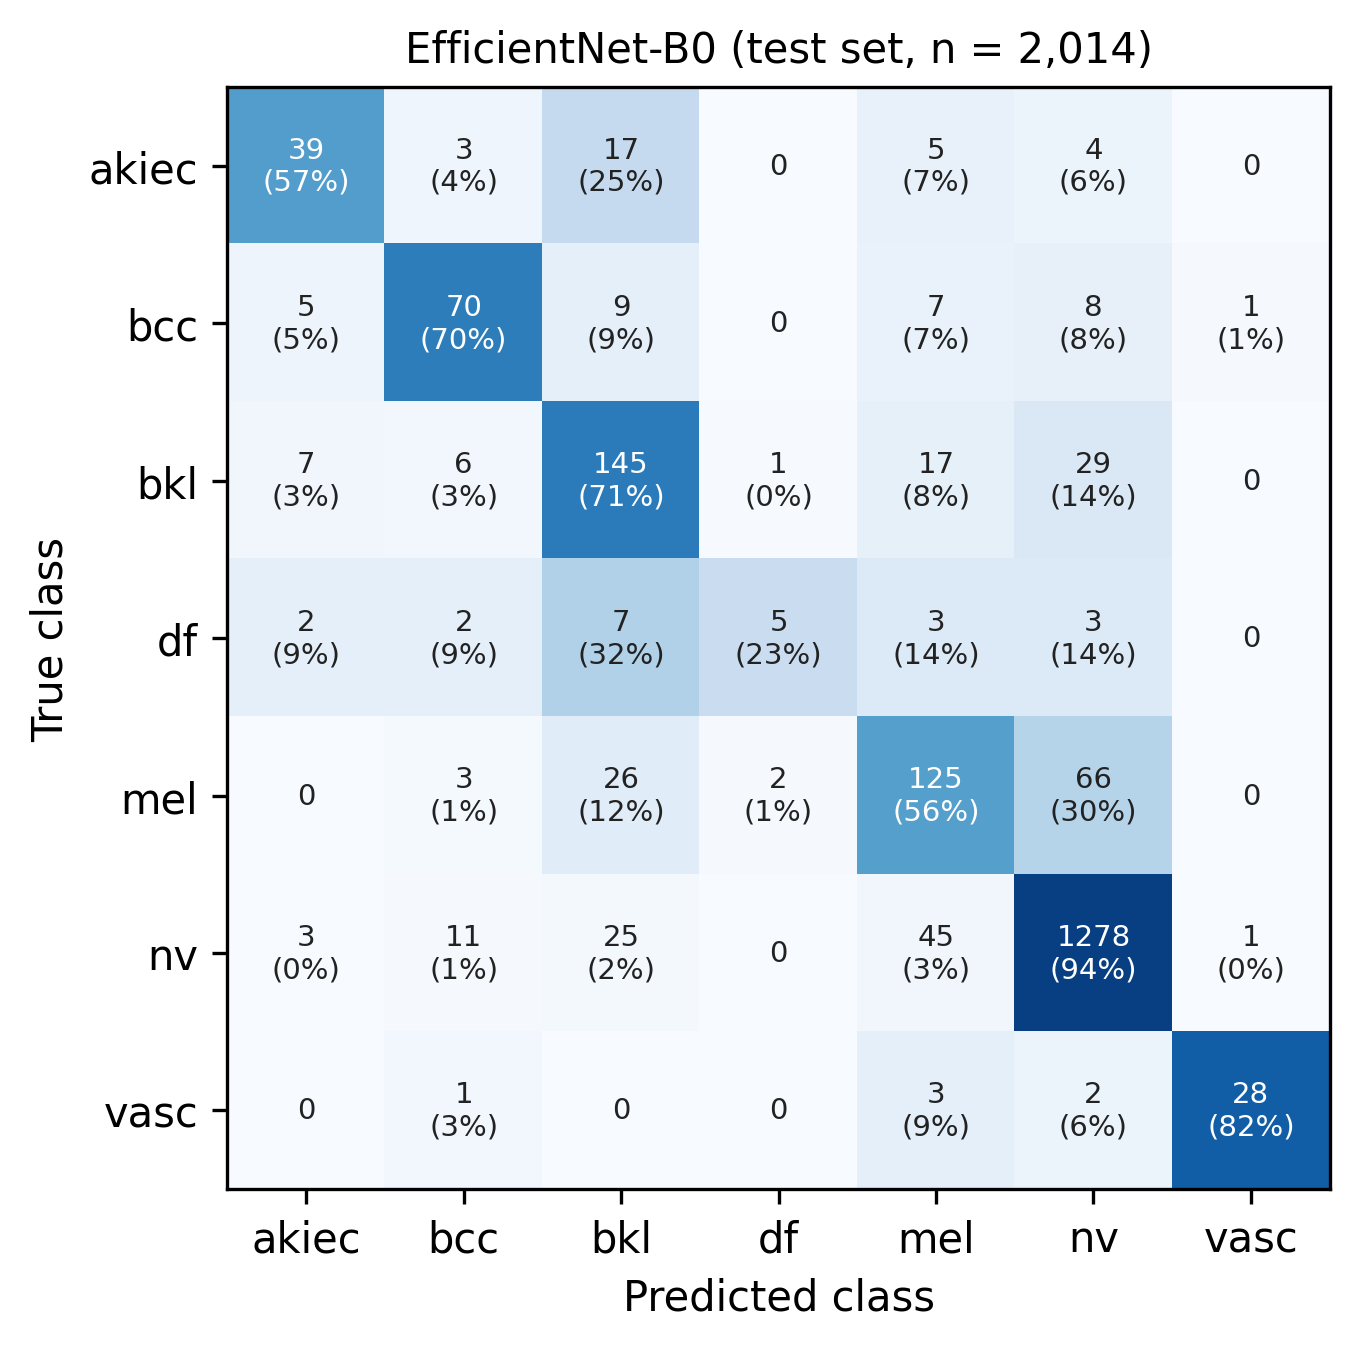


===== EfficientNet-V2-S =====
              precision    recall  f1-score   support

       akiec     0.8000    0.5294    0.6372        68
         bcc     0.6990    0.7200    0.7094       100
         bkl     0.5709    0.7463    0.6469       205
          df     0.6154    0.3636    0.4571        22
         mel     0.5370    0.5225    0.5297       222
          nv     0.9228    0.9039    0.9133      1363
        vasc     0.9118    0.9118    0.9118        34

    accuracy                         0.8183      2014
   macro avg     0.7224    0.6711    0.6865      2014
weighted avg     0.8257    0.8183    0.8194      2014

       akiec  bcc  bkl  df  mel    nv  vasc
akiec     36    6   23   0    1     2     0
bcc        1   72   10   3    4    10     0
bkl        5   10  153   1   11    25     0
df         0    3    6   8    1     4     0
mel        1    3   39   1  116    59     3
nv         2    9   37   0   83  1232     0
vasc       0    0    0   0    0     3    31


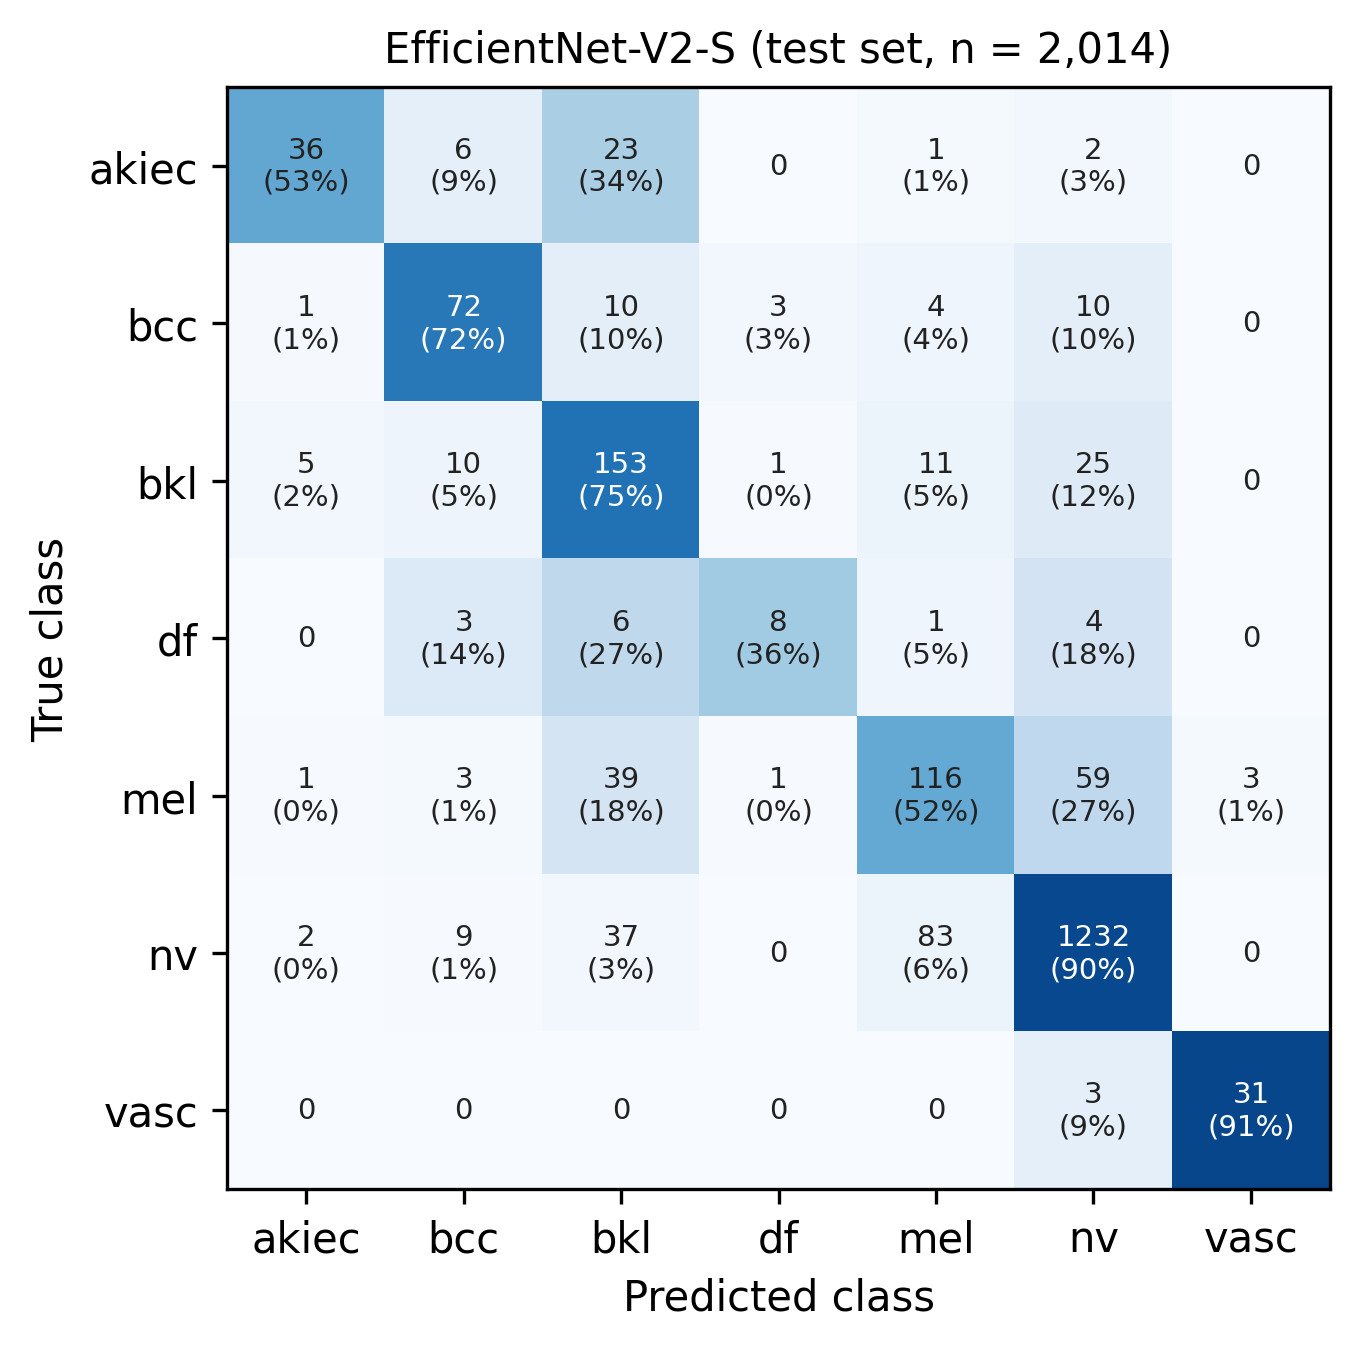

                   test_images  accuracy  balanced_accuracy  macro_f1  \
EfficientNet-B0         2014.0    0.8391             0.6475    0.6763   
EfficientNet-V2-S       2014.0    0.8183             0.6711    0.6865   

                   weighted_f1  melanoma_sensitivity  melanoma_specificity  
EfficientNet-B0         0.8360                0.5631                0.9554  
EfficientNet-V2-S       0.8194                0.5225                0.9442  


In [9]:
# ===== 9. EVALUATE BOTH MODELS ON THE SAME UNSEEN TEST SET =====
summary = {}
for name, model in [("EfficientNet-B0", model_b0), ("EfficientNet-V2-S", model_v2)]:
    yt, yp, _ = predict(model, test_dl)
    cm = confusion_matrix(yt, yp, labels=range(len(CLASSES)))
    pd.DataFrame(cm, index=CLASSES, columns=CLASSES).to_csv(f"{OUT_DIR}/confusion_matrix_{name}.csv")
    rep = classification_report(yt, yp, target_names=CLASSES, digits=4, output_dict=True)
    pd.DataFrame(rep).T.to_csv(f"{OUT_DIR}/classification_report_{name}.csv")
    mel = cls2idx["mel"]; tp = cm[mel, mel]; fn = cm[mel].sum() - tp; fp = cm[:, mel].sum() - tp; tn = cm.sum() - tp - fn - fp
    summary[name] = dict(test_images=int(len(yt)), accuracy=accuracy_score(yt, yp),
                         balanced_accuracy=balanced_accuracy_score(yt, yp),
                         macro_f1=f1_score(yt, yp, average="macro"), weighted_f1=f1_score(yt, yp, average="weighted"),
                         melanoma_sensitivity=tp / (tp + fn), melanoma_specificity=tn / (tn + fp))
    print(f"\n===== {name} =====")
    print(classification_report(yt, yp, target_names=CLASSES, digits=4))
    print(pd.DataFrame(cm, index=CLASSES, columns=CLASSES))
    # confusion matrix figure
    N = cm / cm.sum(1, keepdims=True)
    fig, ax = plt.subplots(figsize=(5.4, 4.6), dpi=300); ax.imshow(N, cmap="Blues", vmin=0, vmax=1)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, f"{cm[i,j]}\n({N[i,j]*100:.0f}%)" if cm[i, j] else "0", ha="center", va="center",
                    fontsize=7, color="white" if N[i, j] > 0.55 else "#222")
    ax.set_xticks(range(len(CLASSES)), CLASSES); ax.set_yticks(range(len(CLASSES)), CLASSES)
    ax.set_xlabel("Predicted class"); ax.set_ylabel("True class"); ax.set_title(f"{name} (test set, n = {len(yt):,})", fontsize=10)
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/confusion_matrix_{name}.png"); plt.show()

json.dump(summary, open(f"{OUT_DIR}/summary_metrics.json", "w"), indent=2)
print(pd.DataFrame(summary).T.round(4))

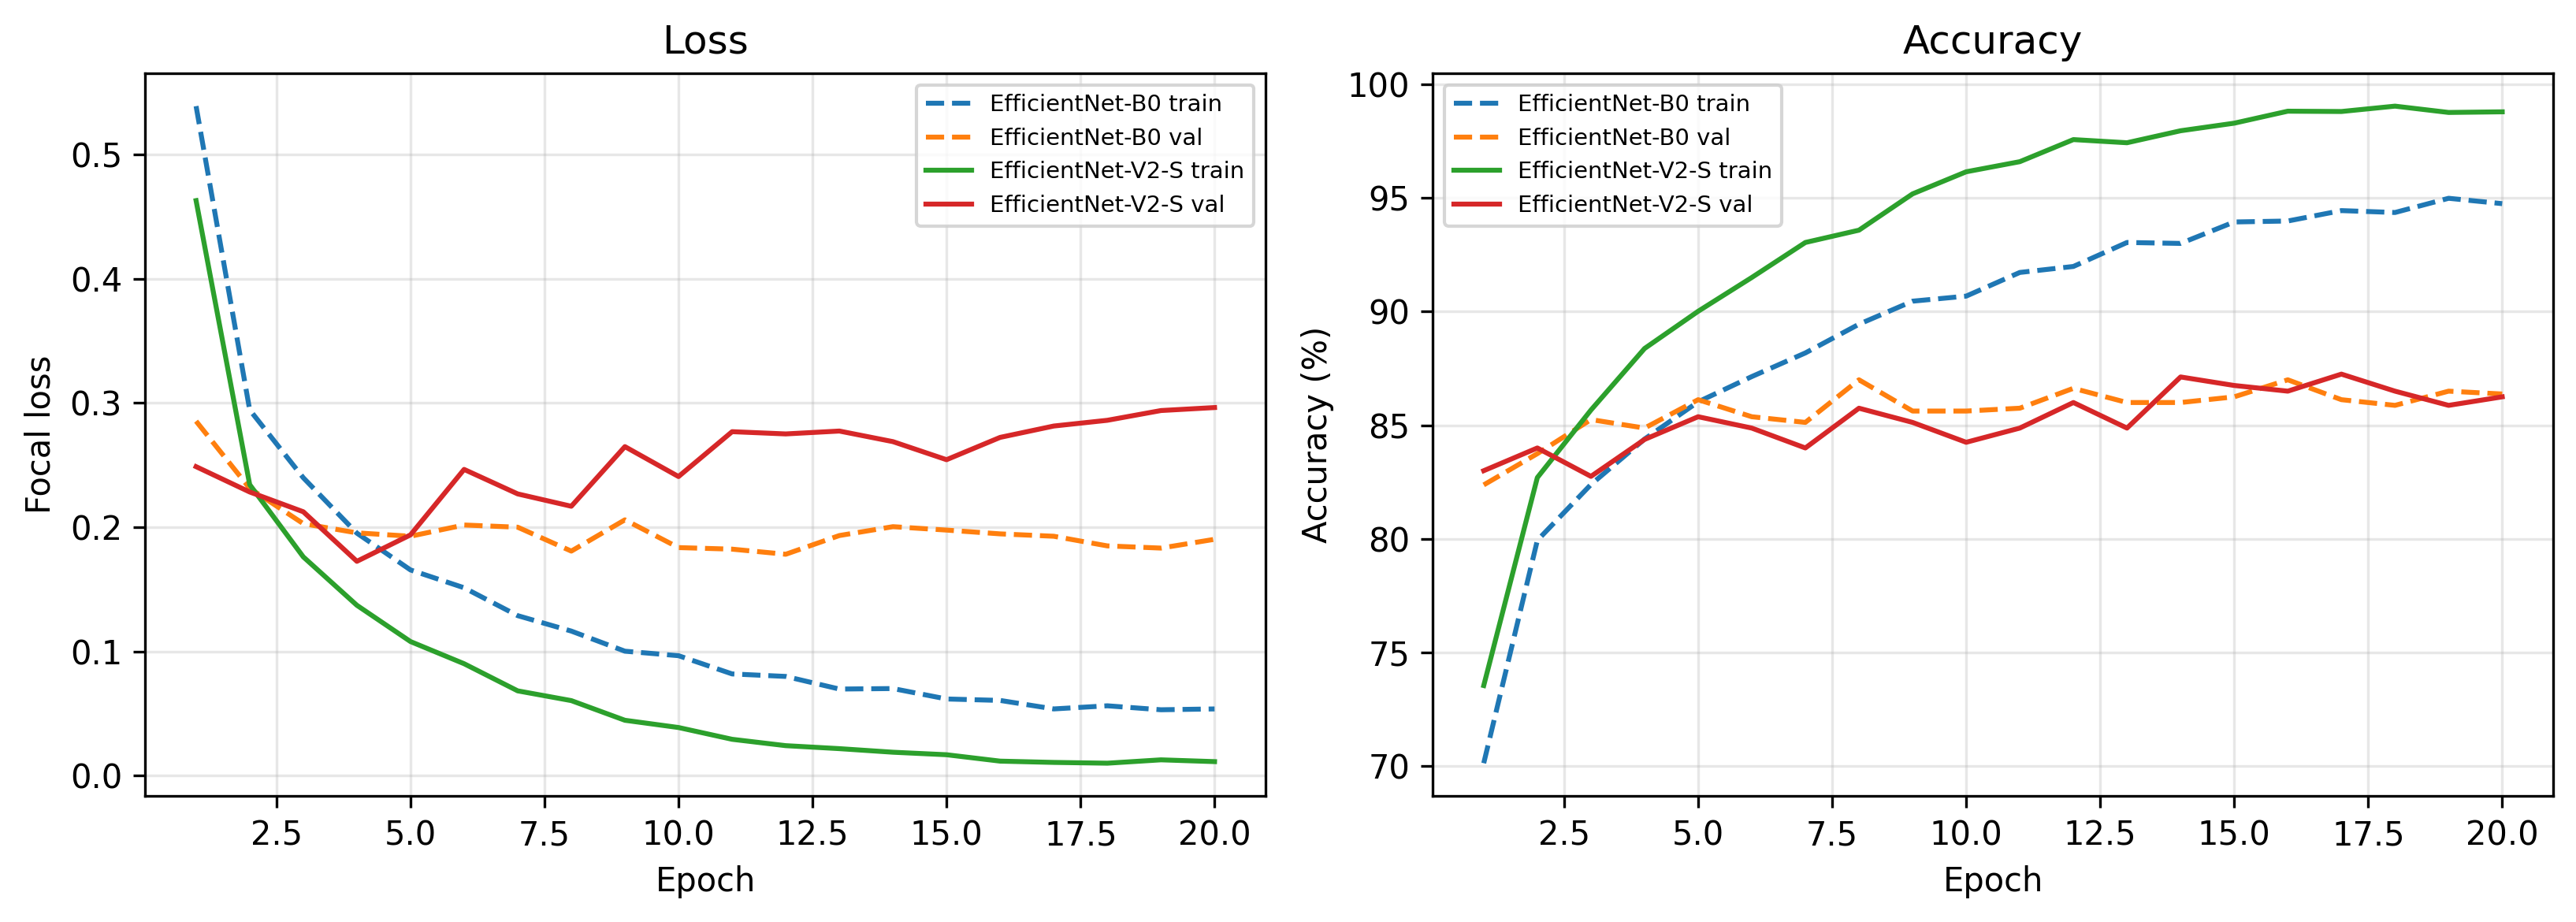

In [10]:
# ===== 10. TRAINING CURVES =====
fig, axs = plt.subplots(1, 2, figsize=(11, 4), dpi=300)
for name, ls in [("EfficientNet-B0", "--"), ("EfficientNet-V2-S", "-")]:
    h = pd.read_csv(f"{OUT_DIR}/history_{name}.csv")
    axs[0].plot(h.epoch, h.train_loss, ls, label=f"{name} train"); axs[0].plot(h.epoch, h.val_loss, ls, label=f"{name} val")
    axs[1].plot(h.epoch, h.train_acc * 100, ls, label=f"{name} train"); axs[1].plot(h.epoch, h.val_acc * 100, ls, label=f"{name} val")
axs[0].set(xlabel="Epoch", ylabel="Focal loss", title="Loss"); axs[1].set(xlabel="Epoch", ylabel="Accuracy (%)", title="Accuracy")
for a in axs: a.legend(fontsize=7); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/training_curves.png"); plt.show()

In [11]:
# ===== 11. PARAMETERS AND INFERENCE TIME =====
info = {}
x1 = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
for name, model in [("EfficientNet-B0", model_b0), ("EfficientNet-V2-S", model_v2)]:
    model.eval()
    with torch.no_grad():
        for _ in range(20): model(x1)
        torch.cuda.synchronize(); t0 = time.time()
        for _ in range(200): model(x1)
        torch.cuda.synchronize()
    info[name] = dict(parameters=sum(p.numel() for p in model.parameters()),
                      inference_ms_per_image_gpu=(time.time() - t0) / 200 * 1000)
info["hardware"] = gpu_name; info["pytorch"] = torch.__version__; info["torchvision"] = torchvision.__version__
info["settings"] = dict(seed=SEED, img_size=IMG_SIZE, batch_size=BATCH_SIZE, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY,
                        optimizer="AdamW", scheduler="CosineAnnealingLR", focal_gamma=FOCAL_GAMMA, focal_alpha=FOCAL_ALPHA,
                        checkpoint="best validation macro-F1", split="lesion-level 72/8/20 (StratifiedGroupKFold)")
json.dump(info, open(f"{OUT_DIR}/model_info.json", "w"), indent=2); print(json.dumps(info, indent=2))

{
  "EfficientNet-B0": {
    "parameters": 4016515,
    "inference_ms_per_image_gpu": 8.780683279037476
  },
  "EfficientNet-V2-S": {
    "parameters": 20186455,
    "inference_ms_per_image_gpu": 22.08439588546753
  },
  "hardware": "Tesla T4",
  "pytorch": "2.11.0+cu130",
  "torchvision": "0.26.0+cu130",
  "settings": {
    "seed": 42,
    "img_size": 224,
    "batch_size": 32,
    "epochs": 20,
    "lr": 0.0001,
    "weight_decay": 1e-05,
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "focal_gamma": 2.0,
    "focal_alpha": 1.0,
    "checkpoint": "best validation macro-F1",
    "split": "lesion-level 72/8/20 (StratifiedGroupKFold)"
  }
}


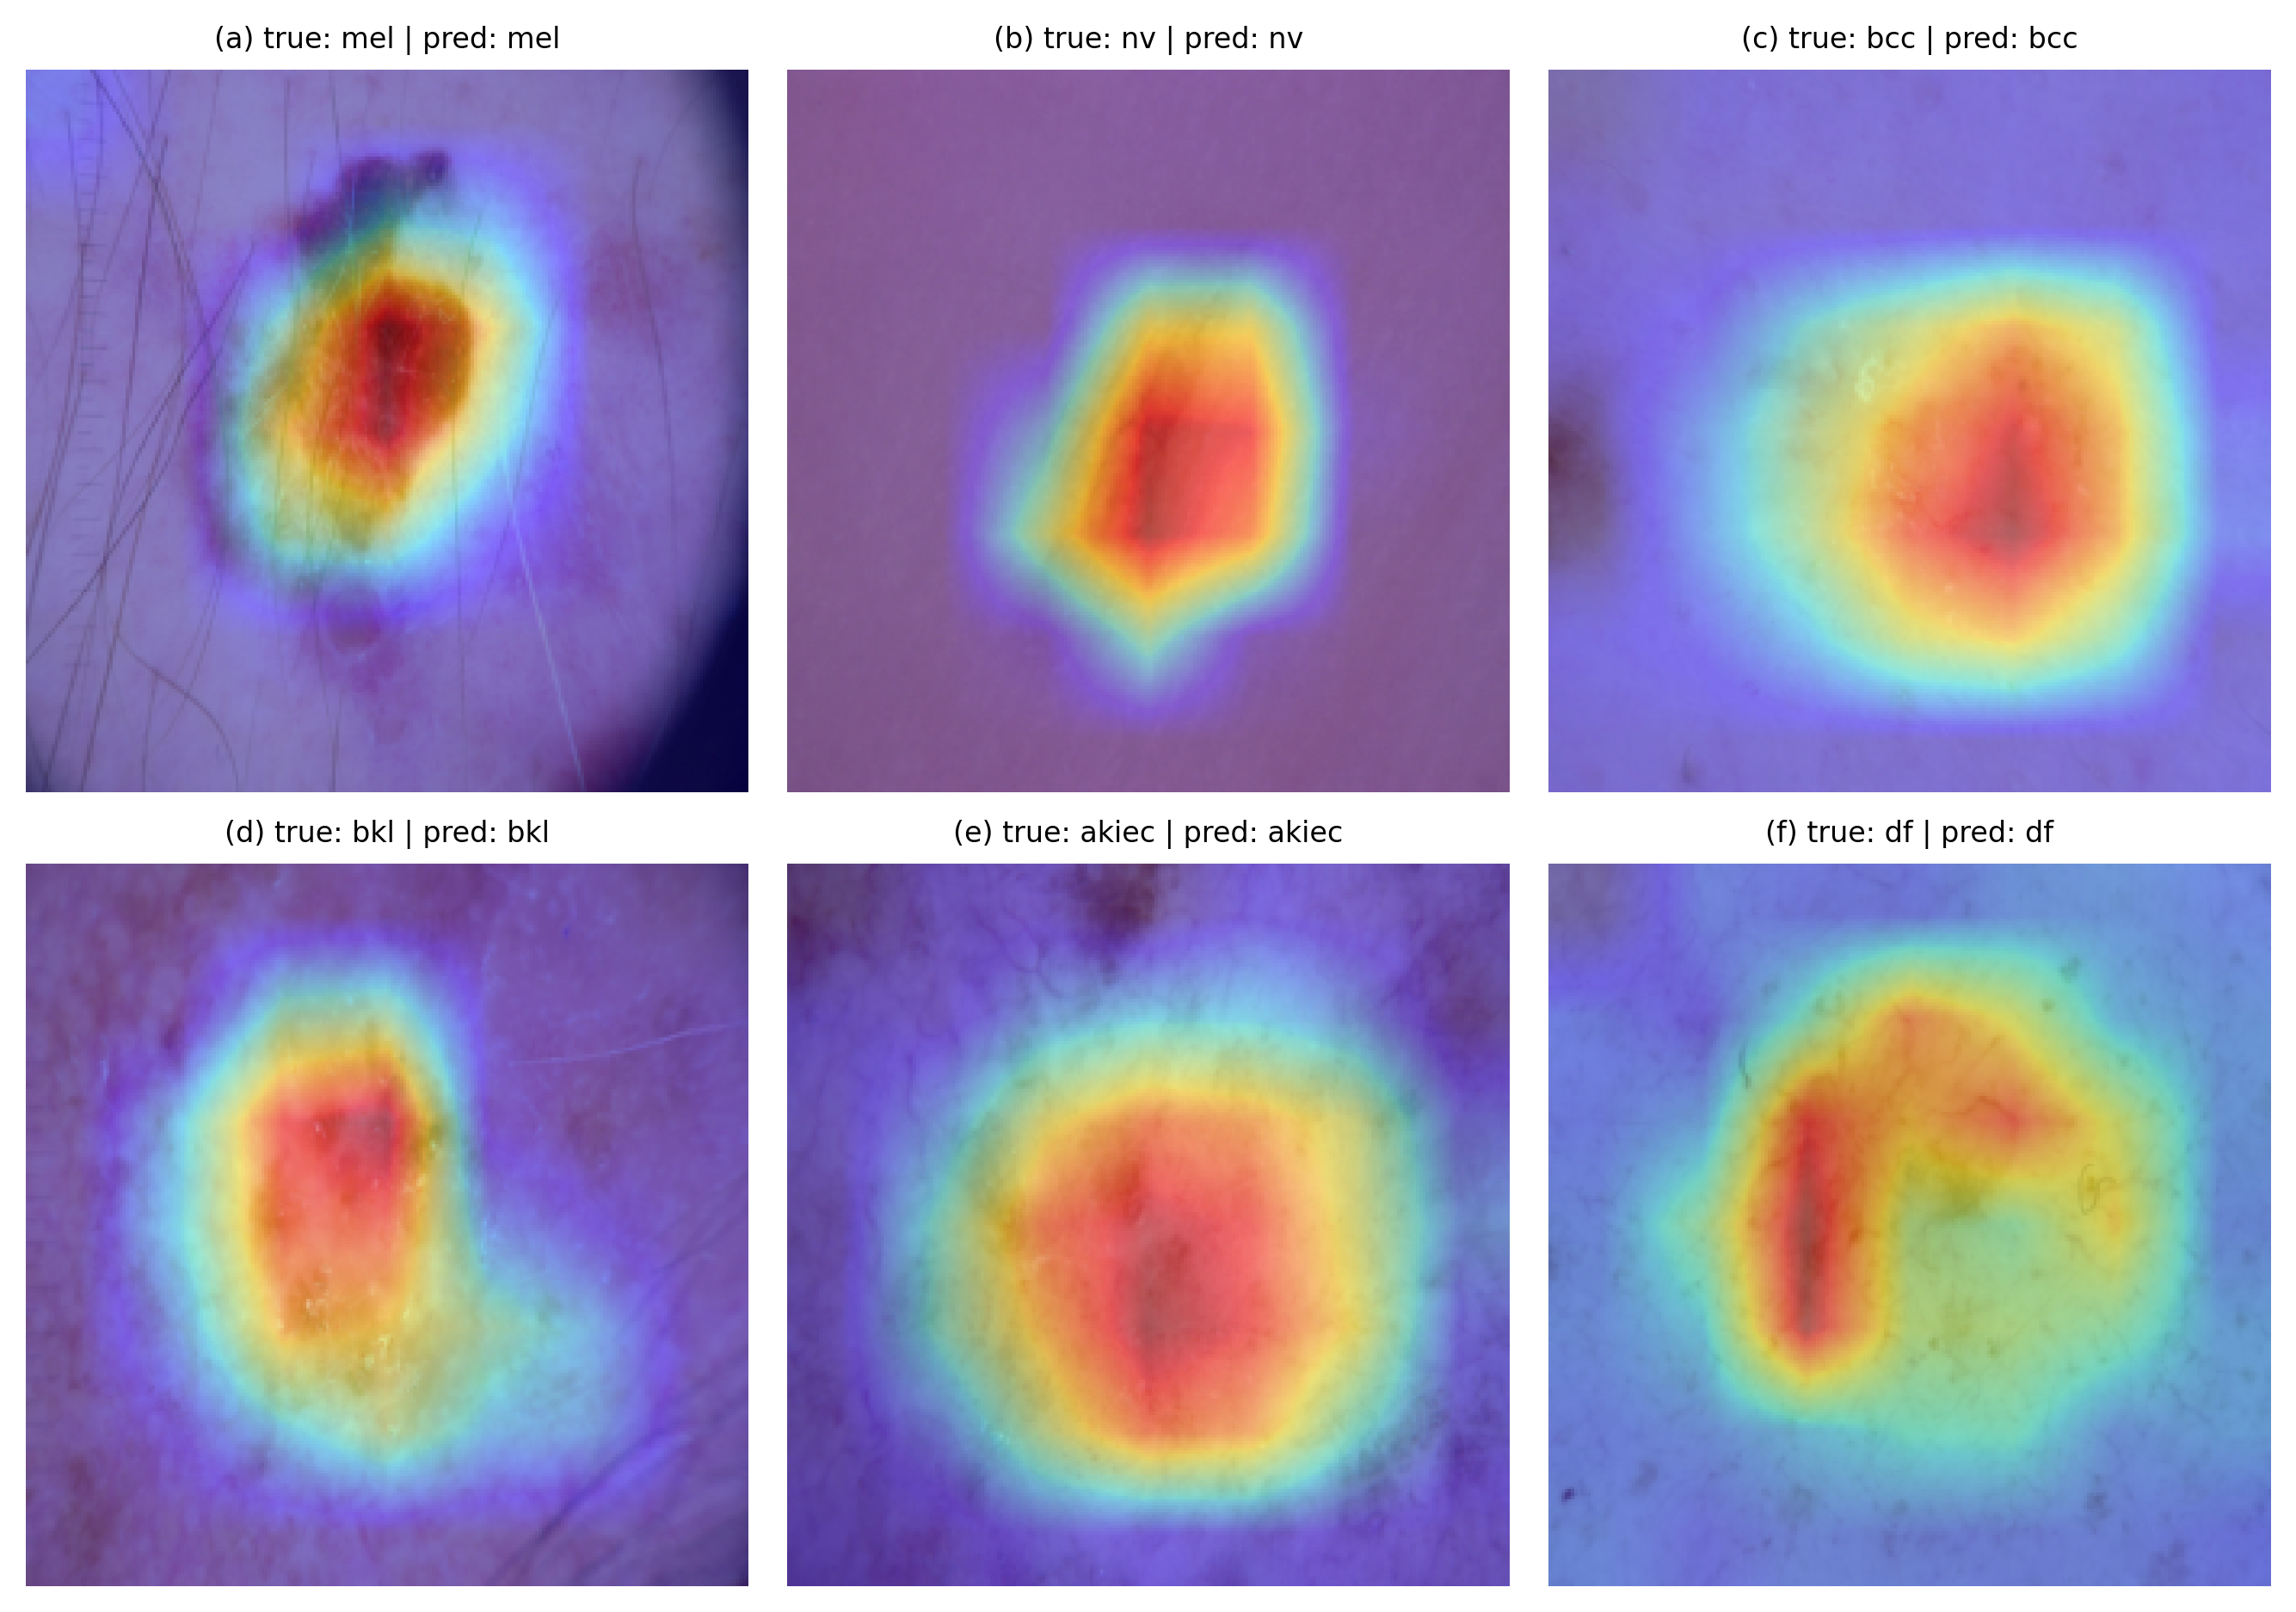

  panel      image_id   true predicted
0     a  ISIC_0026531    mel       mel
1     b  ISIC_0032212     nv        nv
2     c  ISIC_0032384    bcc       bcc
3     d  ISIC_0026769    bkl       bkl
4     e  ISIC_0032173  akiec     akiec
5     f  ISIC_0030321     df        df


In [12]:
# ===== 12. GRAD-CAM FIGURE (EfficientNet-V2-S, last conv layer, correct RGB colours) =====
class GradCAM:
    def __init__(self, model, layer):
        self.m, self.a, self.g = model, None, None
        def fwd(mod, i, o):
            self.a = o.detach()
            if o.requires_grad:
                o.register_hook(lambda grad: setattr(self, "g", grad.detach()))
        layer.register_forward_hook(fwd)
    def __call__(self, x, c):
        self.m.zero_grad(); out = self.m(x); out[0, c].backward()
        w = self.g.mean((2, 3), keepdim=True); cam = F.relu((w * self.a).sum(1))[0]
        cam = F.interpolate(cam[None, None], size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)[0, 0]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8); return cam.cpu().numpy(), out.argmax(1).item()

model_v2.eval(); cammer = GradCAM(model_v2, model_v2.features[-1])
picks, want = [], ["mel", "nv", "bcc", "bkl", "akiec", "df"]
test_meta = meta.loc[test_idx]
for c in want:
    picks.append(test_meta[test_meta.dx == c].index[0])
fig, axs = plt.subplots(2, 3, figsize=(9, 6.4), dpi=300); rows = []
for ax, j, letter in zip(axs.flat, picks, "abcdef"):
    img = IMAGES[j]; x = test_tf(Image.fromarray(img))[None].to(device)
    with torch.no_grad(): pred = model_v2(x).argmax(1).item()
    cam, _ = cammer(x, pred)
    heat = plt.cm.jet(cam)[..., :3]
    ax.imshow(0.55 * img / 255 + 0.45 * heat); ax.axis("off")
    true_c, pred_c = meta.at[j, "dx"], CLASSES[pred]
    ax.set_title(f"({letter}) true: {true_c} | pred: {pred_c}", fontsize=8)
    rows.append(dict(panel=letter, image_id=meta.at[j, "image_id"], true=true_c, predicted=pred_c))
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/gradcam_examples.png"); plt.show()
pd.DataFrame(rows).to_csv(f"{OUT_DIR}/gradcam_examples.csv", index=False); print(pd.DataFrame(rows))

In [13]:
# ===== 13. ZIP RESULTS AND DOWNLOAD =====
shutil.make_archive("/content/results_for_paper", "zip", OUT_DIR)
from google.colab import files
files.download("/content/results_for_paper.zip")
print("Done. Send results_for_paper.zip back.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. Send results_for_paper.zip back.


Predictions reproduce the saved confusion matrices: OK
{
 "a_correct_b_wrong": 149,
 "a_wrong_b_correct": 107,
 "p_value_exact": 0.010252807453529638
}


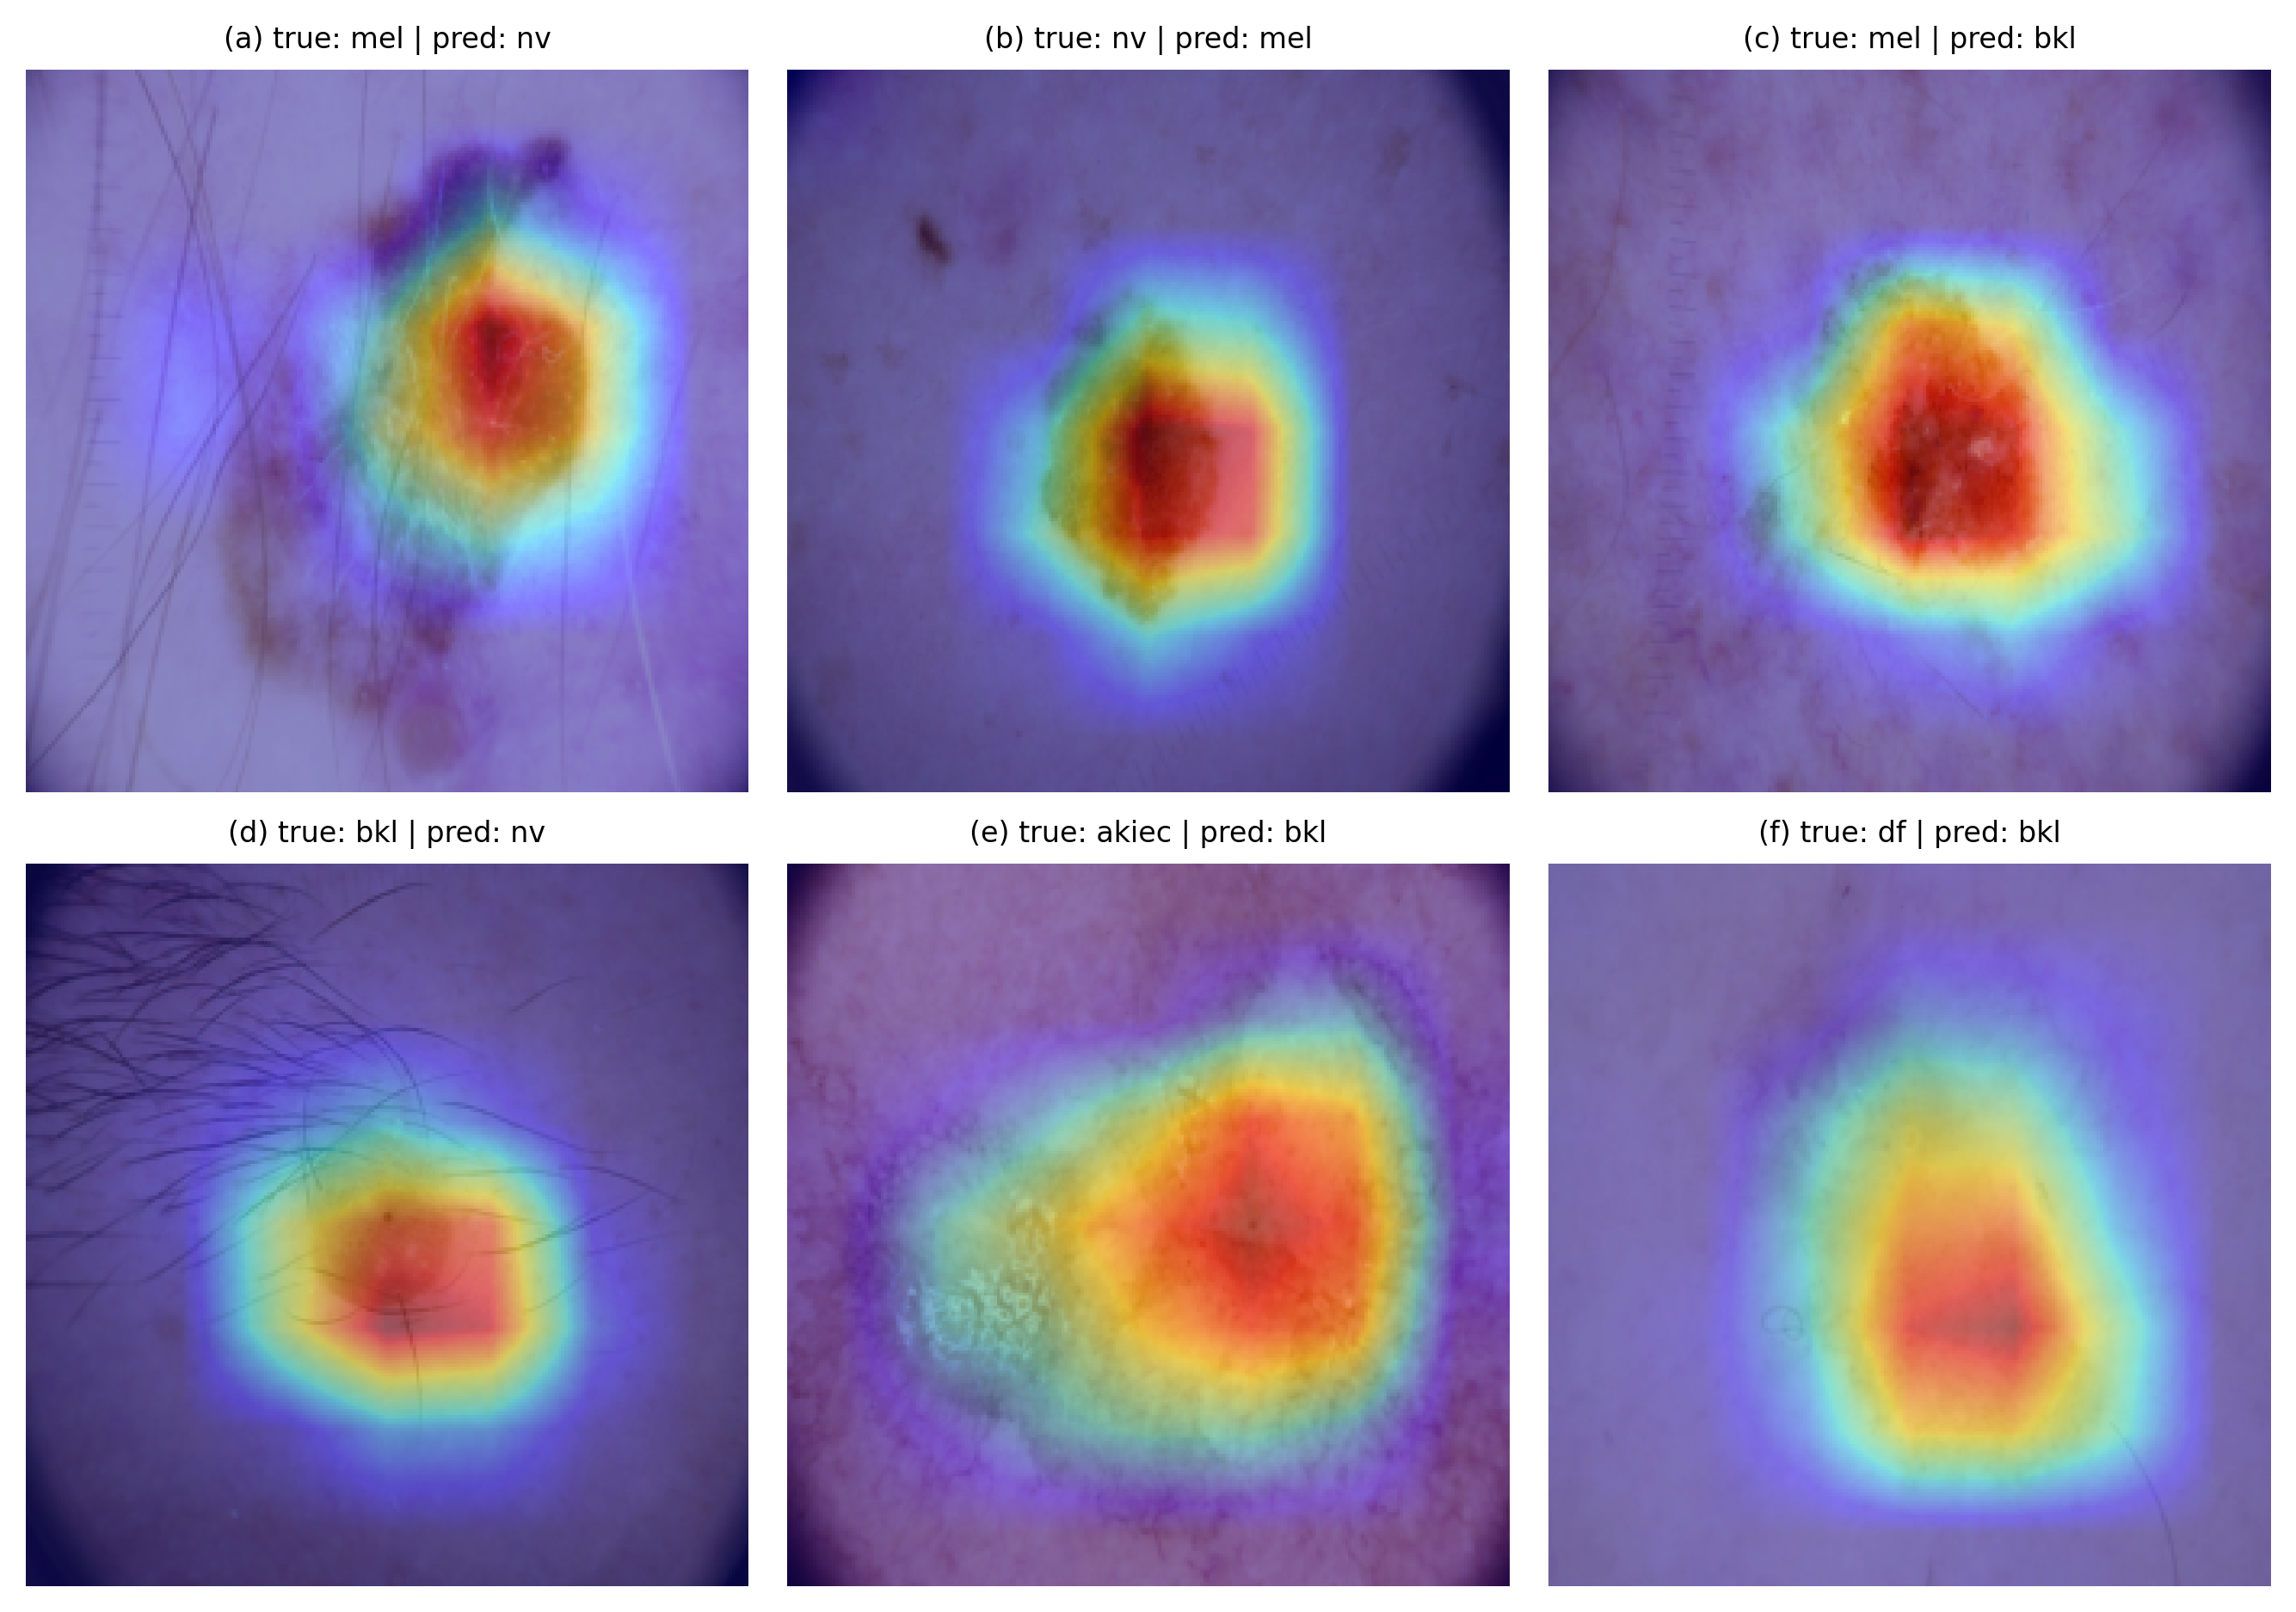

/tmp/ipykernel_3473/4017970742.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


EfficientNet-B0_CE | epoch  1/20 | train loss 0.8938 acc 0.7114 | val loss 0.5395 acc 0.8225 macroF1 0.5744 | 40s  <- best (saved)
EfficientNet-B0_CE | epoch  2/20 | train loss 0.5734 acc 0.7899 | val loss 0.4478 acc 0.8488 macroF1 0.6636 | 54s  <- best (saved)
EfficientNet-B0_CE | epoch  3/20 | train loss 0.4753 acc 0.8304 | val loss 0.4296 acc 0.8562 macroF1 0.6771 | 41s  <- best (saved)
EfficientNet-B0_CE | epoch  4/20 | train loss 0.4260 acc 0.8450 | val loss 0.4149 acc 0.8425 macroF1 0.6605 | 41s
EfficientNet-B0_CE | epoch  5/20 | train loss 0.3752 acc 0.8618 | val loss 0.4010 acc 0.8512 macroF1 0.6799 | 42s  <- best (saved)
EfficientNet-B0_CE | epoch  6/20 | train loss 0.3190 acc 0.8808 | val loss 0.4050 acc 0.8538 macroF1 0.7101 | 40s  <- best (saved)
EfficientNet-B0_CE | epoch  7/20 | train loss 0.2891 acc 0.8957 | val loss 0.4049 acc 0.8638 macroF1 0.7342 | 41s  <- best (saved)
EfficientNet-B0_CE | epoch  8/20 | train loss 0.2718 acc 0.8988 | val loss 0.4030 acc 0.8588 macroF1

/tmp/ipykernel_3473/4017970742.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


EfficientNet-V2-S_CE | epoch  1/20 | train loss 0.7791 acc 0.7413 | val loss 0.4368 acc 0.8575 macroF1 0.6448 | 53s  <- best (saved)
EfficientNet-V2-S_CE | epoch  2/20 | train loss 0.4730 acc 0.8353 | val loss 0.4304 acc 0.8475 macroF1 0.6957 | 53s  <- best (saved)
EfficientNet-V2-S_CE | epoch  3/20 | train loss 0.3628 acc 0.8717 | val loss 0.4521 acc 0.8263 macroF1 0.6809 | 53s
EfficientNet-V2-S_CE | epoch  4/20 | train loss 0.2893 acc 0.8947 | val loss 0.4313 acc 0.8525 macroF1 0.7025 | 53s  <- best (saved)
EfficientNet-V2-S_CE | epoch  5/20 | train loss 0.2496 acc 0.9110 | val loss 0.4344 acc 0.8662 macroF1 0.7255 | 53s  <- best (saved)
EfficientNet-V2-S_CE | epoch  6/20 | train loss 0.2059 acc 0.9231 | val loss 0.5017 acc 0.8413 macroF1 0.6993 | 53s
EfficientNet-V2-S_CE | epoch  7/20 | train loss 0.1749 acc 0.9399 | val loss 0.4461 acc 0.8525 macroF1 0.7345 | 53s  <- best (saved)
EfficientNet-V2-S_CE | epoch  8/20 | train loss 0.1297 acc 0.9560 | val loss 0.4881 acc 0.8600 macroF1 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. Send results_extra.zip back.


In [14]:
# ===== 14. EXTRA ANALYSES FOR REVIEW =====
# Paste this into a NEW cell at the bottom of the SAME Colab session (after cells 1-13 have run), then run it.
# It (a) saves per-image test predictions, (b) runs a paired McNemar test, (c) computes lesion-level bootstrap CIs,
# (d) draws Grad-CAM for misclassified images, (e) runs a cross-entropy vs focal-loss ablation (optional),
# and (f) zips everything as results_extra.zip.
import numpy as np, pandas as pd, json, time, shutil, os, torch, torch.nn.functional as F
from scipy.stats import binomtest
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score, confusion_matrix

RUN_CE_ABLATION = True          # set False to skip the ~35-minute cross-entropy ablation
N_BOOT = 2000
EXTRA = "/content/results_extra"; os.makedirs(EXTRA, exist_ok=True)
MEL = cls2idx["mel"]
test_lesions = meta.loc[test_idx, "lesion_id"].values

def metrics(t, p):
    K = len(CLASSES); cm = np.bincount(t * K + p, minlength=K * K).reshape(K, K)
    tp = np.diag(cm).astype(float); sup = cm.sum(1); pred = cm.sum(0)
    rec = np.divide(tp, sup, out=np.zeros(K), where=sup > 0); prec = np.divide(tp, pred, out=np.zeros(K), where=pred > 0)
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros(K), where=(prec + rec) > 0)
    present = sup > 0
    return dict(accuracy=tp.sum() / cm.sum(), balanced_accuracy=rec[present].mean(),
                macro_f1=f1.mean(), weighted_f1=(f1 * sup).sum() / sup.sum(),
                melanoma_sensitivity=rec[MEL],
                melanoma_specificity=(cm.sum() - sup[MEL] - pred[MEL] + cm[MEL, MEL]) / (cm.sum() - sup[MEL]))

# rows of the test set belonging to each lesion (for lesion-level resampling)
_, inv = np.unique(test_lesions, return_inverse=True)
rows_by_lesion = [np.where(inv == g)[0] for g in range(inv.max() + 1)]
rng = np.random.default_rng(SEED)
BOOT = [np.concatenate([rows_by_lesion[g] for g in rng.integers(0, len(rows_by_lesion), len(rows_by_lesion))]) for _ in range(N_BOOT)]

def lesion_bootstrap(t, pa, pb=None):
    """95% percentile CIs, resampling whole lesions. If pb is given, also CI of the difference pa - pb."""
    A, D = [], []
    for r in BOOT:
        ma = metrics(t[r], pa[r]); A.append(list(ma.values()))
        if pb is not None:
            mb = metrics(t[r], pb[r]); D.append([ma[k] - mb[k] for k in ma])
    keys = list(metrics(t, pa).keys())
    out = {k: dict(value=metrics(t, pa)[k], ci_low=float(np.percentile(np.array(A)[:, i], 2.5)),
                   ci_high=float(np.percentile(np.array(A)[:, i], 97.5))) for i, k in enumerate(keys)}
    diff = None
    if pb is not None:
        diff = {k: dict(diff=metrics(t, pa)[k] - metrics(t, pb)[k], ci_low=float(np.percentile(np.array(D)[:, i], 2.5)),
                        ci_high=float(np.percentile(np.array(D)[:, i], 97.5))) for i, k in enumerate(keys)}
    return out, diff

def mcnemar(t, pa, pb):
    b = int(((pa == t) & (pb != t)).sum()); c = int(((pa != t) & (pb == t)).sum())
    return dict(a_correct_b_wrong=b, a_wrong_b_correct=c, p_value_exact=float(binomtest(min(b, c), b + c, 0.5).pvalue) if b + c else 1.0)

# ---- (a) per-image predictions of the selected checkpoints ----
yt, p_b0, _ = predict(model_b0, test_dl)
_,  p_v2, _ = predict(model_v2, test_dl)
for name, p in [("EfficientNet-B0", p_b0), ("EfficientNet-V2-S", p_v2)]:     # consistency check with cell 9
    saved = pd.read_csv(f"{OUT_DIR}/confusion_matrix_{name}.csv", index_col=0).values
    assert (confusion_matrix(yt, p, labels=range(len(CLASSES))) == saved).all(), f"{name}: predictions differ from cell 9!"
print("Predictions reproduce the saved confusion matrices: OK")
pred_df = pd.DataFrame({"image_id": meta.loc[test_idx, "image_id"].values, "lesion_id": test_lesions,
                        "true": [CLASSES[i] for i in yt], "pred_EfficientNet-B0": [CLASSES[i] for i in p_b0],
                        "pred_EfficientNet-V2-S": [CLASSES[i] for i in p_v2]})
pred_df.to_csv(f"{EXTRA}/test_predictions.csv", index=False)

# ---- (b) + (c) paired test and lesion-level bootstrap ----
report = {"test_images": int(len(yt)), "test_lesions": int(len(rows_by_lesion)), "bootstrap": f"{N_BOOT} lesion-level resamples, percentile 95% CI"}
report["EfficientNet-B0"], report["difference_B0_minus_V2S"] = lesion_bootstrap(yt, p_b0, p_v2)
report["EfficientNet-V2-S"], _ = lesion_bootstrap(yt, p_v2)
report["mcnemar_B0_vs_V2S"] = mcnemar(yt, p_b0, p_v2)
print(json.dumps(report["mcnemar_B0_vs_V2S"], indent=1))

# ---- (d) Grad-CAM for misclassified images (EfficientNet-V2-S) ----
if "cammer" not in globals():
    cammer = GradCAM(model_v2, model_v2.features[-1])
model_v2.eval()
wanted = [("mel", "nv"), ("nv", "mel"), ("mel", "bkl"), ("bkl", "nv"), ("akiec", "bkl"), ("df", "bkl")]
fig, axs = plt.subplots(2, 3, figsize=(9, 6.4), dpi=300); rows = []
for ax, (tc, pc), letter in zip(axs.flat, wanted, "abcdef"):
    hit = pred_df[(pred_df.true == tc) & (pred_df["pred_EfficientNet-V2-S"] == pc)]
    if hit.empty: ax.axis("off"); continue
    j = test_idx[hit.index[0]]
    img = IMAGES[j]; x = test_tf(Image.fromarray(img))[None].to(device)
    cam, _ = cammer(x, cls2idx[pc])
    ax.imshow(0.55 * img / 255 + 0.45 * plt.cm.jet(cam)[..., :3]); ax.axis("off")
    ax.set_title(f"({letter}) true: {tc} | pred: {pc}", fontsize=8)
    rows.append(dict(panel=letter, image_id=meta.at[j, "image_id"], true=tc, predicted=pc))
plt.tight_layout(); plt.savefig(f"{EXTRA}/gradcam_misclassified.png"); plt.show()
pd.DataFrame(rows).to_csv(f"{EXTRA}/gradcam_misclassified.csv", index=False)

# ---- (e) ablation: plain cross-entropy (focal loss with gamma = 0 is exactly cross-entropy) ----
if RUN_CE_ABLATION:
    def build(name):                                        # allow names such as "EfficientNet-B0_CE"
        base = name.split("_")[0]
        m = (models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1) if base == "EfficientNet-B0"
             else models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1))
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(CLASSES)); return m.to(device)
    _g = FOCAL_GAMMA; FOCAL_GAMMA = 0.0
    abl = {}
    for base, p_focal in [("EfficientNet-B0", p_b0), ("EfficientNet-V2-S", p_v2)]:
        m = train(base + "_CE")                             # same protocol, only the loss differs
        _, p_ce, _ = predict(m, test_dl)
        shutil.copy(f"{OUT_DIR}/history_{base}_CE.csv", EXTRA)
        pred_df[f"pred_{base}_CE"] = [CLASSES[i] for i in p_ce]
        ci, diff = lesion_bootstrap(yt, p_focal, p_ce)
        abl[base] = dict(cross_entropy=lesion_bootstrap(yt, p_ce)[0], focal_minus_ce=diff, mcnemar_focal_vs_ce=mcnemar(yt, p_focal, p_ce))
        del m; torch.cuda.empty_cache()
    FOCAL_GAMMA = _g
    report["ablation_cross_entropy"] = abl
    pred_df.to_csv(f"{EXTRA}/test_predictions.csv", index=False)

# ---- timing details (for the methods text) ----
report["timing_method"] = ("batch size 1, random 224x224 input already on the GPU, FP32, model.eval() and torch.no_grad(), "
                           "20 warm-up passes, 200 timed passes, torch.cuda.synchronize() before and after timing; "
                           "excludes image loading, preprocessing, host-to-device transfer and Grad-CAM")
json.dump(report, open(f"{EXTRA}/extra_analyses.json", "w"), indent=2, default=float)

# ---- (f) checkpoints of the reported models, then zip and download ----
for f in ["/content/EfficientNet-B0_best.pth", "/content/EfficientNet-V2-S_best.pth"]:
    if os.path.exists(f): shutil.copy(f, EXTRA)
shutil.make_archive("/content/results_extra", "zip", EXTRA)
from google.colab import files
files.download("/content/results_extra.zip")
print("Done. Send results_extra.zip back.")
